# Projet Machine Learning — Prédiction du Chômage des Diplômés Tunisiens
## Phase 1 : Chargement et Découverte du Dataset

**Auteur :** Boudriga Ahmed  
**Dataset :** Enquête Nationale Population et Emploi 2017 (ENPE 2017) — INS Tunisie  
**Source :** https://www.ins.tn/enquetes/enquete-nationale-sur-la-population-et-lemploi-2017  
**Date :** 2025–2026

---

### Définition du Problème

La Tunisie souffre d'un paradoxe économique majeur : le taux de chômage des diplômés du supérieur atteint **23,7 %** (INS, T2 2023), soit le double de la moyenne nationale. Ce phénomène touche particulièrement les jeunes des régions intérieures et les femmes diplômées.

**Objectif :** Construire un modèle de classification supervisée capable de prédire le statut d'emploi d'un diplômé tunisien — **Employé**, **Chômeur** ou **Inactif** — à partir de ses caractéristiques personnelles, éducatives et géographiques issues de l'enquête ENPE 2017.

**Question ML :** Étant donné les variables socio-démographiques d'un individu (âge, sexe, gouvernorat, niveau d'instruction, milieu de résidence), peut-on prédire automatiquement son statut sur le marché du travail ?

In [1]:
# ── CELLULE 0 : Connexion Google Drive ───────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os

# Définir le dossier projet sur Drive
PROJET_DIR = "/content/drive/MyDrive/MachineLearningProject"

# Créer les sous-dossiers si nécessaire
os.makedirs(f"{PROJET_DIR}/notebooks", exist_ok=True)
os.makedirs(f"{PROJET_DIR}/data",      exist_ok=True)
os.makedirs(f"{PROJET_DIR}/models",    exist_ok=True)

# Se placer dans le dossier projet
os.chdir(PROJET_DIR)

print(f"✅ Drive monté")
print(f"✅ Dossier actuel : {os.getcwd()}")
print(f"✅ Fichiers disponibles :")
for f in sorted(os.listdir(PROJET_DIR)):
    print(f"   → {f}")

Mounted at /content/drive
✅ Drive monté
✅ Dossier actuel : /content/drive/MyDrive/MachineLearningProject
✅ Fichiers disponibles :
   → Amelioration_Tentative
   → Data
   → ENPE_2017.csv
   → README.md
   → data
   → graph
   → models
   → notebooks
   → requirements.txt
   → src


---
## 1. Installation et Importation des Librairies

Avant de commencer, nous installons et importons toutes les librairies nécessaires à cette phase d'exploration :
- **pyreadstat** : lecture des fichiers SAS (.sas7bdat) produits par l'INS
- **pandas / numpy** : manipulation et analyse des données
- **matplotlib / seaborn** : visualisations graphiques

In [2]:
import sys
!{sys.executable} -m pip install pyreadstat -q
print("✅ Installation OK")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 27.5 MB/s eta 0:00:00
✅ Installation OK


In [3]:
import pyreadstat
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.1f}'.format)

print("✅ Imports OK")

✅ Imports OK


---
## 2. Chargement du Dataset

Le fichier source est **enpe2t17fipuf.sas7bdat**, fichier individus de l'ENPE 2017 fourni par l'INS Tunisie au format SAS. Il contient les réponses individuelles anonymisées de l'enquête nationale sur la population et l'emploi, portant sur 452 928 individus répartis sur les 24 gouvernorats tunisiens.

Nous utilisons la librairie `pyreadstat` pour lire ce format et récupérer également les métadonnées (labels des variables).

In [4]:
from google.colab import drive
import pyreadstat

drive.mount('/content/drive')

# Chemin CORRECT (avec "Colab Notebooks" au milieu)
FICHIER = '/content/drive/MyDrive/Colab Notebooks/MachineLearningProject/notebooks/enpe2t17fipuf.sas7bdat'

df, meta = pyreadstat.read_sas7bdat(FICHIER)

print("=" * 55)
print(" DATASET ENPE 2017 - INS TUNISIE")
print("=" * 55)
print(f" Lignes : {df.shape[0]:>10}")
print(f" Colonnes : {df.shape[1]:>10}")
print(f" Taille mém : {df.memory_usage(deep=True).sum() / 1e6:>9.1f} MB")
print("=" * 55)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 DATASET ENPE 2017 - INS TUNISIE
 Lignes :     452928
 Colonnes :         20
 Taille mém :      72.5 MB


---
## 3. Dictionnaire des Variables

L'INS Tunisie utilise des codes de variables (ex: `V_9_10_i`, `V_1_204_i`) dont la signification est documentée dans le questionnaire officiel de l'ENPE 2017. Cette cellule affiche le dictionnaire complet des 20 variables avec leurs libellés officiels, types et nombre de valeurs uniques.

Cette étape est essentielle pour comprendre la sémantique de chaque colonne avant toute analyse.

In [5]:
col_labels = {col: (meta.column_labels[i] or "")
              for i, col in enumerate(df.columns)}

print("\n📌 DICTIONNAIRE DES VARIABLES\n")
print(f"{'Colonne':<15} {'Label (INS)':<45} {'Type':<10} {'Uniques':>7}")
print("-" * 80)

for i, col in enumerate(df.columns):
    label = meta.column_labels[i] if meta.column_labels and i < len(meta.column_labels) else ""
    label = label or ""
    dtype = str(df[col].dtype)
    nuniq = df[col].nunique()
    print(f"{col:<15} {label:<45} {dtype:<10} {nuniq:>7}")


📌 DICTIONNAIRE DES VARIABLES

Colonne         Label (INS)                                   Type       Uniques
--------------------------------------------------------------------------------
V_9_10_i        GOUVERNORAT                                   float64         24
Num_Men         Numéro ordre du ménage dans le gouvernorat    float64       7439
V_9_11_1        Milieu de résidence                           float64          2
V_1_201_i       Numéro d'ordre de l'individu dans le ménage   float64         16
V_1_203_i       Lien de Parenté                               float64          8
V_1_204_i       Etat de résidence                             float64          2
V_1_205_i       Genre                                         float64          2
V_210tr         Age de l'individu                             float64         76
V_1_225_i       Etat Matrimonial                              float64          4
V_0_244_i       Niveau d'instruction                          float64         

---
## 4. Aperçu des Données

Nous affichons les 20 premières lignes du dataset pour avoir une vue concrète de la structure des données : format numérique des codes, présence de valeurs manquantes (NaN), et ordre des observations.

In [6]:
print("\n📋 20 PREMIÈRES LIGNES\n")
pd.set_option('display.max_columns', None)
print(df.head(20).to_string())


📋 20 PREMIÈRES LIGNES

    V_9_10_i  Num_Men  V_9_11_1  V_1_201_i  V_1_203_i  V_1_204_i  V_1_205_i  V_210tr  V_1_225_i  V_0_244_i  V_4_321_i  V_4_325_i  V_0_331_i  V_4_305_2  V_5_600_i  V_5_613_i  V_5_640_i  V_5_643_i  V_0_580_i  weight
0       11.0      1.0       1.0        1.0        1.0        1.0        1.0     61.0        2.0        3.0        NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN        3.0    60.1
1       11.0      1.0       1.0        2.0        2.0        1.0        2.0     59.0        2.0        3.0        NaN        NaN        NaN        NaN        NaN        NaN        NaN        NaN        3.0    60.0
2       11.0      1.0       1.0        3.0        3.0        1.0        2.0     27.0        1.0        3.0        NaN        NaN        NaN        5.0        3.0        NaN       24.0        NaN        2.0   101.7
3       11.0      1.0       1.0        4.0        3.0        1.0        2.0     29.0        1.0        3.0        3.0   

---
## 5. Décodage des Variables Clés

Les variables du fichier ENPE sont encodées sous forme de codes numériques. Nous utilisons le dictionnaire officiel du questionnaire INS pour décoder les valeurs et comprendre la distribution réelle de chaque modalité.

Les variables les plus importantes pour notre projet sont :
- **V_9_10_i** : Gouvernorat (24 gouvernorats)
- **V_1_204_i** : Sexe (1=Masculin, 2=Féminin)
- **V_1_225_i** : Niveau d'instruction (1=Sans diplôme → 4=Supérieur)
- **V_0_244_i** : Situation dans l'emploi → **notre variable cible**

In [7]:
col_labels = {col: (meta.column_labels[i] or "")
              for i, col in enumerate(df.columns)}

LABELS = {
    "V_9_10_i": {
        11:"Tunis", 12:"Ariana", 13:"Ben Arous", 14:"Manouba",
        15:"Nabeul", 16:"Zaghouan", 17:"Bizerte",
        21:"Béja", 22:"Jendouba", 23:"Kef", 24:"Siliana",
        31:"Sousse", 32:"Monastir", 33:"Mahdia", 34:"Sfax",
        41:"Kairouan", 42:"Kasserine", 43:"Sidi Bouzid",
        51:"Gabès", 52:"Médenine", 53:"Tataouine",
        61:"Gafsa", 62:"Tozeur", 63:"Kébili"
    },
    "V_9_11_1" : {1:"Communal (urbain)", 2:"Non communal (rural)"},
    "V_1_204_i": {1:"Masculin", 2:"Féminin"},
    "V_1_205_i": {1:"Célibataire", 2:"Marié(e)", 3:"Divorcé(e)", 4:"Veuf/Veuve"},
    "V_1_225_i": {1:"Sans diplôme", 2:"Enseignement de base",
                  3:"Secondaire", 4:"Supérieur"},
    "V_0_244_i": {1:"Chômeur", 2:"Employé", 3:"Inactif",
                  4:"Moins de 15 ans", 9:"Non déclaré"},
}

print("\n🔍 VALEURS UNIQUES PAR COLONNE\n")
print("-" * 60)

for col in ["V_9_10_i", "V_9_11_1", "V_1_204_i",
            "V_1_205_i", "V_1_225_i", "V_0_244_i"]:
    label = col_labels.get(col, "")
    print(f"\n  {col}  —  {label}")
    if col in LABELS:
        for code, nom in LABELS[col].items():
            count = (df[col] == code).sum()
            pct   = count / len(df) * 100
            print(f"    {code} = {nom:<35} ({count:>7,} · {pct:5.1f}%)")
    else:
        print(f"    Valeurs : {sorted(df[col].dropna().unique()[:8])}")


🔍 VALEURS UNIQUES PAR COLONNE

------------------------------------------------------------

  V_9_10_i  —  GOUVERNORAT
    11 = Tunis                               ( 21,614 ·   4.8%)
    12 = Ariana                              ( 16,984 ·   3.7%)
    13 = Ben Arous                           ( 18,142 ·   4.0%)
    14 = Manouba                             ( 18,134 ·   4.0%)
    15 = Nabeul                              ( 19,862 ·   4.4%)
    16 = Zaghouan                            ( 14,159 ·   3.1%)
    17 = Bizerte                             ( 20,449 ·   4.5%)
    21 = Béja                                ( 16,739 ·   3.7%)
    22 = Jendouba                            ( 16,950 ·   3.7%)
    23 = Kef                                 ( 18,398 ·   4.1%)
    24 = Siliana                             ( 15,649 ·   3.5%)
    31 = Sousse                              ( 20,648 ·   4.6%)
    32 = Monastir                            ( 18,008 ·   4.0%)
    33 = Mahdia                              ( 

---
## 6. Analyse des Valeurs Manquantes

La gestion des valeurs manquantes est une étape critique du prétraitement. Nous identifions ici les colonnes avec le plus de NaN et leur pourcentage, ce qui orientera notre stratégie d'imputation en Phase 3.

> **Observation attendue :** Certaines colonnes liées à l'emploi (secteur, CSP) ont un fort taux de NaN car elles ne s'appliquent qu'aux personnes actives occupées.


⚠️  VALEURS MANQUANTES

  Colonne  Manquants  % Manquant
V_5_643_i     441290        97.4
V_5_613_i     438115        96.7
V_5_640_i     430892        95.1
V_5_600_i     430172        95.0
V_4_321_i     328909        72.6
V_4_325_i     328909        72.6
V_0_331_i     319340        70.5
V_4_305_2     308087        68.0
V_0_580_i     111836        24.7
V_0_244_i      76771        16.9
V_1_225_i          2         0.0
 V_9_10_i          0         0.0
V_1_201_i          0         0.0
 V_9_11_1          0         0.0
  Num_Men          0         0.0
  V_210tr          0         0.0
V_1_203_i          0         0.0
V_1_204_i          0         0.0
V_1_205_i          0         0.0
   weight          0         0.0


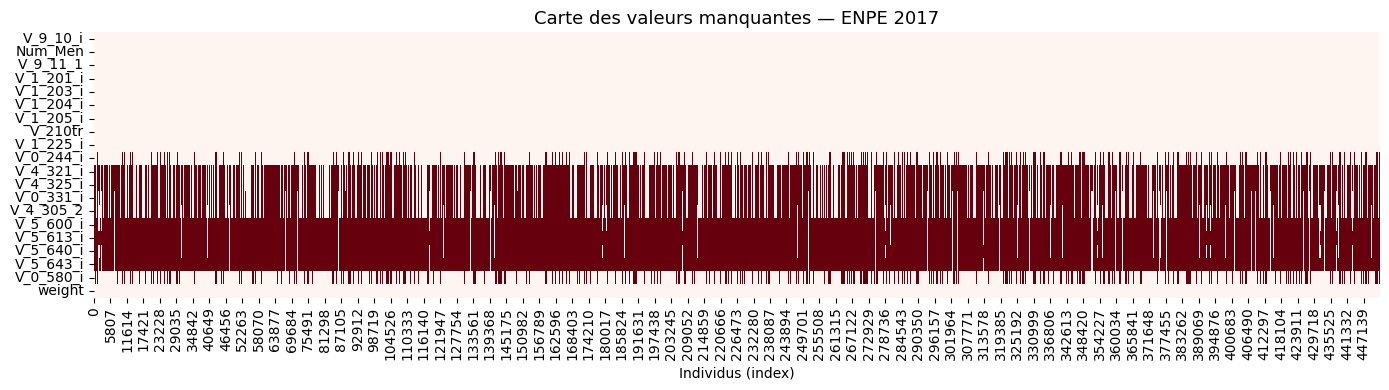

✅ Graphique sauvegardé : nan_heatmap.png


In [8]:
print("\n⚠️  VALEURS MANQUANTES\n")
nan_df = pd.DataFrame({
    "Colonne"   : df.columns,
    "Manquants" : df.isnull().sum().values,
    "% Manquant": (df.isnull().mean() * 100).round(2).values
}).sort_values("Manquants", ascending=False)

print(nan_df.to_string(index=False))

# Heatmap des valeurs manquantes
plt.figure(figsize=(14, 4))
sns.heatmap(df.isnull().T, cbar=False, cmap="Reds",
            yticklabels=df.columns)
plt.title("Carte des valeurs manquantes — ENPE 2017", fontsize=13)
plt.xlabel("Individus (index)")
plt.tight_layout()
plt.savefig("nan_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé : nan_heatmap.png")

---
## 7. Statistiques Descriptives

Les statistiques descriptives (moyenne, écart-type, min, max, quartiles) donnent une première vue quantitative de la distribution de chaque variable numérique. Elles permettent de détecter des outliers potentiels, des erreurs de saisie (ex: âge = 0) et de comprendre l'étendue des valeurs.

In [9]:
print("\n📈 STATISTIQUES DESCRIPTIVES\n")
print(df.describe().round(1).to_string())


📈 STATISTIQUES DESCRIPTIVES

       V_9_10_i  Num_Men  V_9_11_1  V_1_201_i  V_1_203_i  V_1_204_i  V_1_205_i  V_210tr  V_1_225_i  V_0_244_i  V_4_321_i  V_4_325_i  V_0_331_i  V_4_305_2  V_5_600_i  V_5_613_i  V_5_640_i  V_5_643_i  V_0_580_i   weight
count  452928.0 452928.0  452928.0   452928.0   452928.0   452928.0   452928.0 452928.0   452926.0   376157.0   124019.0   124019.0   133588.0   144841.0    22756.0    14813.0    22036.0    11638.0   341092.0 452928.0
mean       32.7   2609.9       1.4        2.7        2.4        1.0        1.5     33.1        1.5        2.5        2.9        5.8       61.6        5.9        2.8       77.6       18.8        6.5        2.2     25.2
std        16.3   1583.5       0.5        1.6        1.1        0.1        0.5     21.3        0.6        1.1        1.0       10.4       31.4        2.5        2.3       21.5       20.7        2.9        0.9     18.8
min        11.0      1.0       1.0        1.0        1.0        1.0        1.0      0.0        1.0

---
## 8. Distribution de la Variable Cible

La variable cible de notre projet est **V_0_244_i** (Situation dans l'emploi). Cette cellule affiche et visualise la distribution des 4 modalités initiales :
- **Code 1** → Chômeur (ayant déjà ou jamais travaillé)
- **Code 2** → Employé (actif occupé)
- **Code 3** → Inactif (hors marché du travail)
- **Codes 4 et 9** → Exclus (moins de 15 ans / non déclarés)

> **Note :** Les codes 4 et 9 seront filtrés en Phase 3 (Preprocessing).


🎯 FOCUS VARIABLE CIBLE : V_0_244_i

  1 — Chômeur                        69,522  ( 15.3%)  ███████████████
  2 — Employé                       116,925  ( 25.8%)  █████████████████████████
  3 — Inactif                       141,033  ( 31.1%)  ███████████████████████████████
  4 — Moins de 15 ans                44,577  (  9.8%)  █████████
  9 — Non déclaré                     4,100  (  0.9%)  


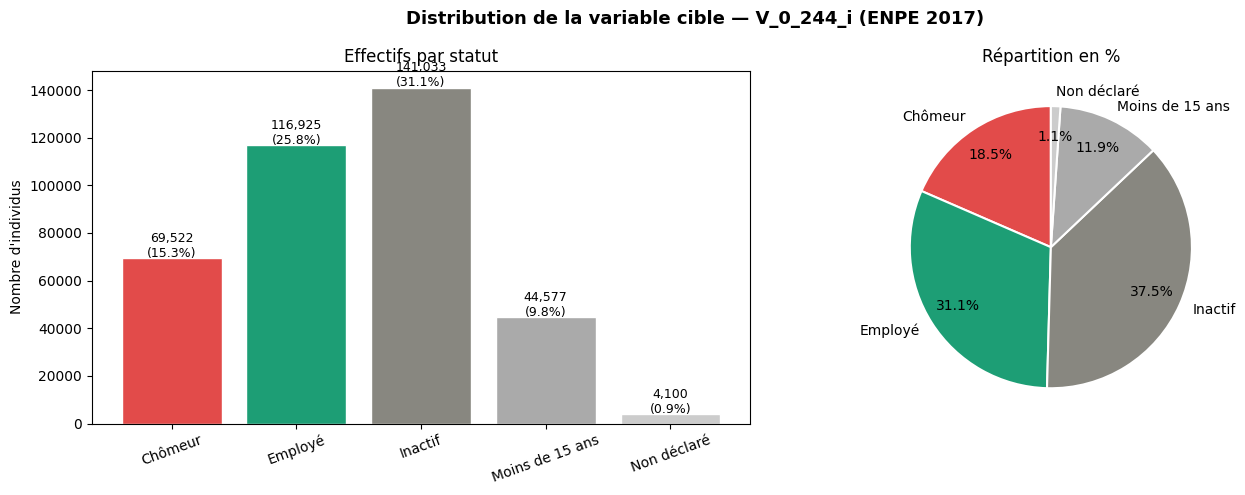

✅ Graphique sauvegardé : distribution_cible.png


In [10]:
print("\n🎯 FOCUS VARIABLE CIBLE : V_0_244_i\n")

LABELS_CIBLE = {
    1: "Chômeur",
    2: "Employé",
    3: "Inactif",
    4: "Moins de 15 ans",
    9: "Non déclaré"
}
COLORS_CIBLE = {1:"#E24B4A", 2:"#1D9E75", 3:"#888780",
                4:"#AAAAAA", 9:"#CCCCCC"}

cible = df["V_0_244_i"].value_counts().sort_index()

for code, count in cible.items():
    nom = LABELS_CIBLE.get(int(code), str(code))
    pct = count / len(df) * 100
    bar = "█" * int(pct / 1)
    print(f"  {int(code)} — {nom:<28} {count:>8,}  ({pct:5.1f}%)  {bar}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution de la variable cible — V_0_244_i (ENPE 2017)",
             fontsize=13, fontweight="bold")

noms   = [LABELS_CIBLE.get(int(c), str(c)) for c in cible.index]
colors = [COLORS_CIBLE.get(int(c), "#999999") for c in cible.index]

axes[0].bar(noms, cible.values, color=colors, edgecolor="white")
axes[0].set_title("Effectifs par statut")
axes[0].set_ylabel("Nombre d'individus")
axes[0].tick_params(axis="x", rotation=20)
for bar, val in zip(axes[0].patches, cible.values):
    pct = val / len(df) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 500,
                 f"{val:,}\n({pct:.1f}%)", ha="center", fontsize=9)

axes[1].pie(cible.values, labels=noms, colors=colors,
            autopct="%1.1f%%", startangle=90, pctdistance=0.78,
            wedgeprops={"edgecolor":"white","linewidth":1.5})
axes[1].set_title("Répartition en %")

plt.tight_layout()
plt.savefig("distribution_cible.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé : distribution_cible.png")

---
## 9. Sauvegarde du Dataset

Nous sauvegardons le dataset chargé au format CSV pour faciliter son utilisation dans les phases suivantes (EDA, Preprocessing) sans avoir à recharger le fichier SAS à chaque fois.

In [11]:
df.to_csv("ENPE_2017.csv", index=False, encoding="utf-8-sig")
print("\n✅ Dataset sauvegardé en CSV : ENPE_2017.csv")


✅ Dataset sauvegardé en CSV : ENPE_2017.csv


---
## 10. Résumé de la Phase 1

Bilan des découvertes de cette phase d'exploration initiale.

In [12]:
print("\n" + "=" * 55)
print("  RÉSUMÉ PHASE 1 — CHARGEMENT ET DÉCOUVERTE")
print("=" * 55)
print(f"  Dataset      : ENPE 2017 — INS Tunisie")
print(f"  Fichier      : enpe2t17fipuf.sas7bdat")
print(f"  Lignes       : {df.shape[0]:,}")
print(f"  Colonnes     : {df.shape[1]}")
print(f"  NaN total    : {df.isnull().sum().sum():,}")
print(f"  Variable cible : V_0_244_i (5 modalités → 3 après filtrage)")
print(f"")
print(f"  Variables clés identifiées :")
print(f"    → V_9_10_i  : Gouvernorat (24 régions)")
print(f"    → V_1_204_i : Sexe")
print(f"    → V_210tr   : Âge")
print(f"    → V_1_225_i : Niveau d'instruction")
print(f"    → V_0_244_i : Situation dans l'emploi (CIBLE)")
print(f"")
print(f"  Fichiers générés :")
print(f"    → nan_heatmap.png")
print(f"    → distribution_cible.png")
print(f"    → ENPE_2017.csv")
print("=" * 55)
print("\n Phase 1 terminée → Prochaine étape : Phase 2 (EDA)")


  RÉSUMÉ PHASE 1 — CHARGEMENT ET DÉCOUVERTE
  Dataset      : ENPE 2017 — INS Tunisie
  Fichier      : enpe2t17fipuf.sas7bdat
  Lignes       : 452,928
  Colonnes     : 20
  NaN total    : 3,214,323
  Variable cible : V_0_244_i (5 modalités → 3 après filtrage)

  Variables clés identifiées :
    → V_9_10_i  : Gouvernorat (24 régions)
    → V_1_204_i : Sexe
    → V_210tr   : Âge
    → V_1_225_i : Niveau d'instruction
    → V_0_244_i : Situation dans l'emploi (CIBLE)

  Fichiers générés :
    → nan_heatmap.png
    → distribution_cible.png
    → ENPE_2017.csv

 Phase 1 terminée → Prochaine étape : Phase 2 (EDA)
